<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/DL/batch_norm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip install opendatasets

In [20]:
import opendatasets as od

In [21]:
od.download('https://www.kaggle.com/datasets/muhammadsajad/concertriccir2')

Skipping, found downloaded files in "./concertriccir2" (use force=True to force download)


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv('/content/concertriccir2/concertriccir2.csv')

In [24]:
df.head(3)

,7.003345706103683010e-01,-2.470675778972781789e-01,0.000000000000000000e+00
0,-3.950019,2.740080,1.0
1,0.150222,-2.157638,1.0
2,-1.672050,-0.941519,1.0


In [25]:
df.rename(
    columns={
        '7.003345706103683010e-01':'x',
        '-2.470675778972781789e-01' : 'y',
        '0.000000000000000000e+00' : 'class'

    },
    inplace=True
)

In [26]:
X = df.iloc[:, 0:2].values
y = df.iloc[:,-1].values

In [27]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization

In [28]:
model1 = Sequential()
model1.add(Dense(2, activation='relu', input_dim = 2))
model1.add(Dense(2, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
model1.compile(loss = 'binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [31]:
history1 = model1.fit(X, y, epochs = 200, validation_split=0.2)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4731 - loss: 0.6731 - val_accuracy: 0.5100 - val_loss: 0.6948
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4516 - loss: 0.6929 - val_accuracy: 0.5200 - val_loss: 0.6943
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4678 - loss: 0.6725 - val_accuracy: 0.5200 - val_loss: 0.6939
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4443 - loss: 0.6914 - val_accuracy: 0.5200 - val_loss: 0.6935
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5043 - loss: 0.6683 - val_accuracy: 0.5200 - val_loss: 0.6933
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5059 - loss: 0.6728 - val_accuracy: 0.5300 - val_loss: 0.6931
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5028 - loss: 0.6729 - val_accuracy: 0.5300 - val_loss: 0.6929
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5069 - loss: 0.6653 - val_accuracy: 0.

In [32]:
model2 = Sequential()

model2.add(Dense(3, activation='relu', input_dim = 2))
model2.add(BatchNormalization())
model2.add(Dense(2, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dense(1, activation='sigmoid'))

In [33]:
model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [34]:
model2.compile(loss = 'binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [38]:
history2 = model2.fit(X, y, epochs=200, validation_split=0.2)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4744 - loss: 0.7831 - val_accuracy: 0.5400 - val_loss: 0.8010
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4271 - loss: 0.7744 - val_accuracy: 0.5200 - val_loss: 0.7748
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4488 - loss: 0.7655 - val_accuracy: 0.5100 - val_loss: 0.7570
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4433 - loss: 0.7573 - val_accuracy: 0.5100 - val_loss: 0.7442
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4796 - loss: 0.7121 - val_accuracy: 0.5000 - val_loss: 0.7351
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4563 - loss: 0.7469 - val_accuracy: 0.5000 - val_loss: 0.7268
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4657 - loss: 0.7245 - val_accuracy: 0.5000 - val_loss: 0.7189
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4838 - loss: 0.7230 - val_accuracy: 0.5000 -

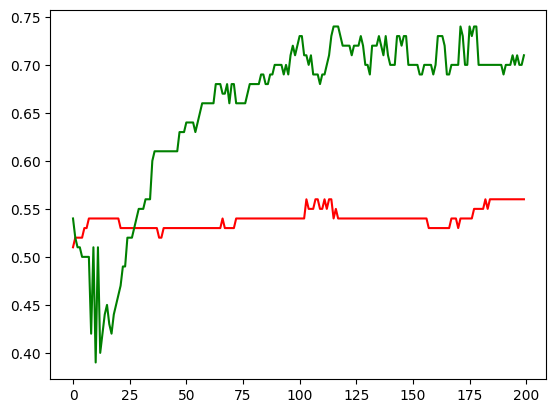

In [39]:
plt.plot(history1.history['val_accuracy'], color = 'r')
plt.plot(history2.history['val_accuracy'], color = 'g')